###Loan Approval Prediction using Machine Learning

Objective:
Build an end-to-end machine learning pipeline to predict loan approval based on applicant information using Logistic Regression.

**Tech Stack:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [114]:
import numpy as np
import pandas as pd
import os

In [53]:
train_df=pd.read_csv('train.csv')
train_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [54]:
test_df=pd.read_csv('test.csv')
test_df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural


In [55]:
import matplotlib.pyplot as plt
import seaborn as sns


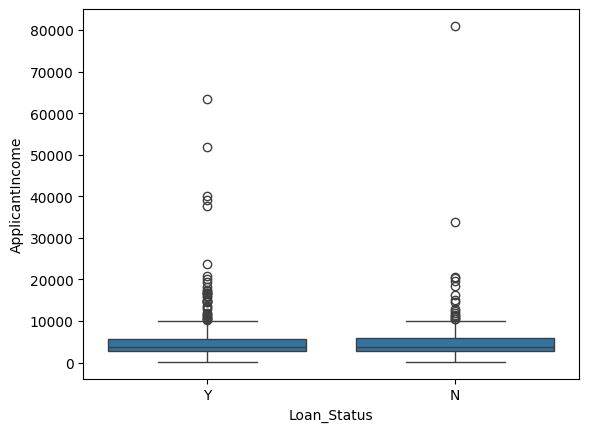

In [56]:
sns.boxplot(x='Loan_Status', y='ApplicantIncome',data=df)
plt.show()

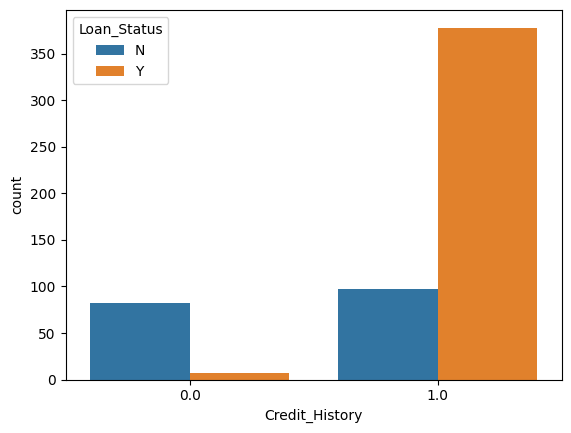

In [57]:
sns.countplot(x='Credit_History',hue='Loan_Status',data=df)
plt.show()

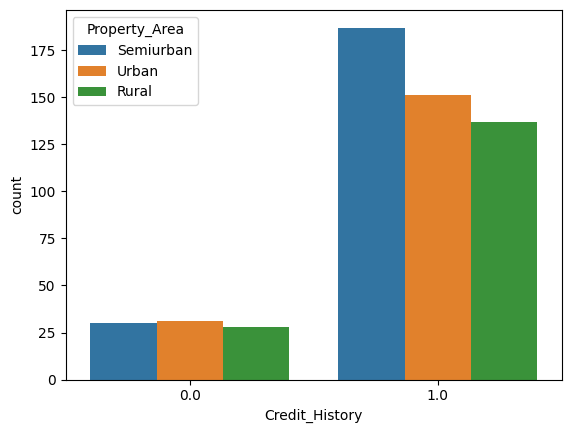

In [58]:
sns.countplot(x='Credit_History',hue='Property_Area',data=train_df)
plt.show()

In [59]:
from sklearn.model_selection import train_test_split

train_df=train_df.drop('Loan_ID',axis=1,errors='ignore')
test_df=test_df.drop('Loan_ID',axis=1,errors='ignore')

X=train_df.drop('Loan_Status',axis=1)
y=train_df['Loan_Status']

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.1)



In [60]:
train_df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [61]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             356 non-null    object 
 1   Married            367 non-null    object 
 2   Dependents         357 non-null    object 
 3   Education          367 non-null    object 
 4   Self_Employed      344 non-null    object 
 5   ApplicantIncome    367 non-null    int64  
 6   CoapplicantIncome  367 non-null    int64  
 7   LoanAmount         362 non-null    float64
 8   Loan_Amount_Term   361 non-null    float64
 9   Credit_History     338 non-null    float64
 10  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(6)
memory usage: 31.7+ KB


In [ ]:
num_columns=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
cat_columns=['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
special_column=['Credit_History']

for col in num_columns:
  mean_value=X_train[col].mean()

  X_train[col].fillna(mean_value,inplace=True)
  X_val[col].fillna(mean_value,inplace=True)
  test_df[col].fillna(mean_value,inplace=True)

for col in cat_columns:
  mode_value=X_train[col].mode()[0]

  X_train[col].fillna(mode_value,inplace=True)
  X_val[col].fillna(mode_value,inplace=True)
  test_df[col].fillna(mode_value,inplace=True)

for col in special_column:
  mode_value=X_train[col].mode()[0]

  X_train[col].fillna(mode_value,inplace=True)
  X_val[col].fillna(mode_value,inplace=True)
  test_df[col].fillna(mode_value,inplace=True)




In [65]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']

le = LabelEncoder()

for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    test_df[col] = le.transform(test_df[col])



X_train = pd.get_dummies(X_train)
X_val = pd.get_dummies(X_val)
test_df = pd.get_dummies(test_df)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
test_df = test_df.reindex(columns=X_train.columns, fill_value=0)

In [73]:
X_train = X_train.astype(int)
X_val = X_val.astype(int)
test_df = test_df.astype(int)


In [75]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
test_df=scaler.transform(test_df)



In [77]:
X_train

array([[ 0.46748588,  0.71287918, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       [ 0.46748588, -1.40276225, -0.54944226, ...,  1.54483108,
        -0.76564149, -0.70999098],
       [ 0.46748588, -1.40276225, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       ...,
       [ 0.46748588, -1.40276225, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       [-2.13910205,  0.71287918, -0.54944226, ..., -0.64731996,
         1.30609431, -0.70999098],
       [ 0.46748588,  0.71287918, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ]])

In [78]:
X_val

array([[ 4.67485878e-01, -1.40276225e+00, -5.49442256e-01,
        -3.81088199e-01, -2.01998917e-01, -5.48513934e-01,
        -5.77956308e-01,  2.64685682e-01, -2.42899156e+00,
         8.48307826e-01, -4.50127070e-01, -4.38434285e-01,
        -3.12114573e-01, -6.47319964e-01,  1.30609431e+00,
        -7.09990981e-01],
       [ 4.67485878e-01,  7.12879177e-01, -5.49442256e-01,
        -3.81088199e-01, -3.07221808e-01,  2.51145475e-03,
        -3.90971067e-01,  2.64685682e-01,  4.11693485e-01,
         8.48307826e-01, -4.50127070e-01, -4.38434285e-01,
        -3.12114573e-01, -6.47319964e-01,  1.30609431e+00,
        -7.09990981e-01],
       [ 4.67485878e-01, -1.40276225e+00, -5.49442256e-01,
        -3.81088199e-01, -1.09731397e-01, -5.48513934e-01,
        -6.24702619e-01,  2.64685682e-01,  4.11693485e-01,
         8.48307826e-01, -4.50127070e-01, -4.38434285e-01,
        -3.12114573e-01, -6.47319964e-01,  1.30609431e+00,
        -7.09990981e-01],
       [ 4.67485878e-01, -1.40276225e

In [79]:
test_df

array([[ 0.46748588,  0.71287918, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       [ 0.46748588,  0.71287918, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       [ 0.46748588,  0.71287918, -0.54944226, ..., -0.64731996,
        -0.76564149,  1.4084686 ],
       ...,
       [ 0.46748588, -1.40276225, -0.54944226, ..., -0.64731996,
         1.30609431, -0.70999098],
       [ 0.46748588,  0.71287918, -0.54944226, ...,  1.54483108,
        -0.76564149, -0.70999098],
       [ 0.46748588, -1.40276225, -0.54944226, ...,  1.54483108,
        -0.76564149, -0.70999098]])

In [85]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()

In [86]:
clf.fit(X_train,y_train)

LogisticRegression()

In [117]:
y_pred = clf.predict(X_val)

In [118]:
y_pred

array(['N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [119]:
y_val

,Loan_Status
464,N
33,Y
588,Y
15,Y
68,Y
...,...
98,Y
603,Y
114,Y
344,Y


In [120]:
from sklearn.metrics import accuracy_score
accuracy_score(y_val,y_pred)

0.8548387096774194

In [121]:
predictions = clf.predict(test_df)

In [122]:
print(predictions)

['Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'N' 'Y' 'Y' 'Y' 'N' 'N' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y'
 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N'
 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'N' 'Y' 'Y' 'N' 'Y'
 'N' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'Y' 'Y'
 'Y' 'N' 'N' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'N' 'Y' 'N' 'Y